### Importing

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.utils import to_categorical
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense , Input
from sklearn.metrics import classification_report , ConfusionMatrixDisplay 

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "credit_data.csv")
df.head()

,clientid,income,age,loan,LTI,default
0,1,66155.925095,59.017015,8106.532131,0.122537,0
1,2,34415.153966,48.117153,6564.745018,0.190752,0
2,3,57317.170063,63.108049,8020.953296,0.139940,0
3,4,42709.534201,45.751972,6103.642260,0.142911,0
4,5,66952.688845,18.584336,8770.099235,0.130989,1


### EDA

In [22]:
df.shape

(2000, 6)

In [23]:
df.columns

Index(['clientid', 'income', 'age', 'loan', 'LTI', 'default'], dtype='object')

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.isnull().sum()

clientid    0
income      0
age         0
loan        0
LTI         0
default     0
dtype: int64

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clientid  2000 non-null   int64  
 1   income    2000 non-null   float64
 2   age       2000 non-null   float64
 3   loan      2000 non-null   float64
 4   LTI       2000 non-null   float64
 5   default   2000 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 93.9 KB


In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
clientid,2000.0,1000.500000,577.494589,1.000000,500.750000,1000.500000,1500.250000,2000.000000
income,2000.0,45331.600018,14326.327119,20014.489470,32796.459717,45789.117313,57791.281668,69995.685578
age,2000.0,40.927143,13.262450,18.055189,29.062492,41.382673,52.596993,63.971796
loan,2000.0,4444.369695,3045.410024,1.377630,1939.708847,3974.719419,6432.410625,13766.051239
LTI,2000.0,0.098403,0.057620,0.000049,0.047903,0.099437,0.147585,0.199938
default,2000.0,0.141500,0.348624,0.000000,0.000000,0.000000,0.000000,1.000000


In [28]:
df = df.drop(columns = ["clientid"])

In [29]:
df["default"].value_counts()

default
0    1717
1     283
Name: count, dtype: int64

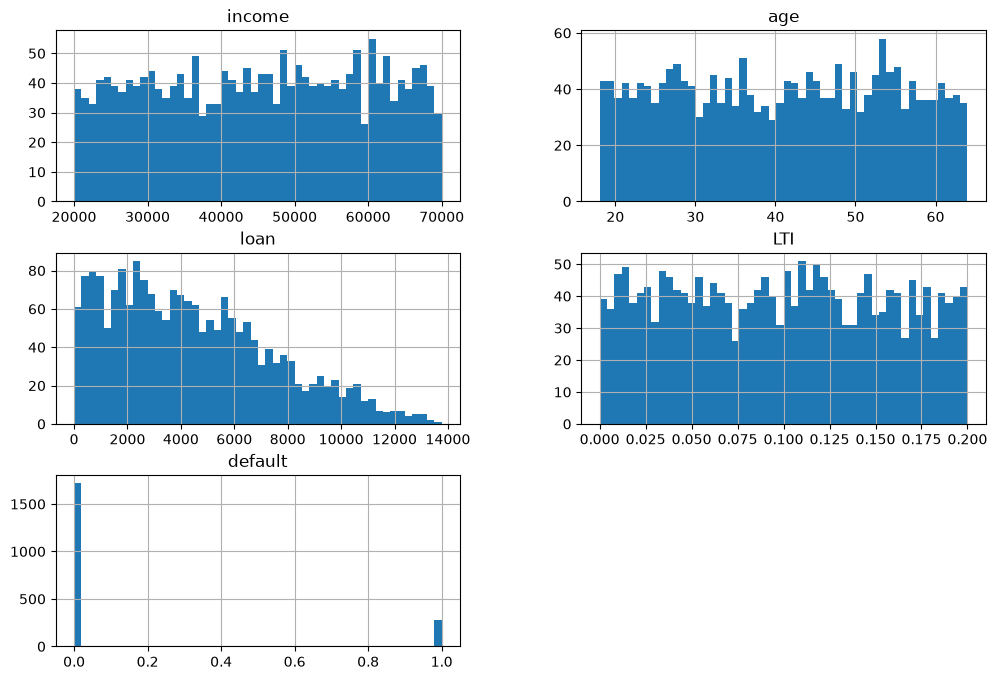

In [30]:
df.hist(bins = 50 , figsize = (12 , 8))
plt.show()

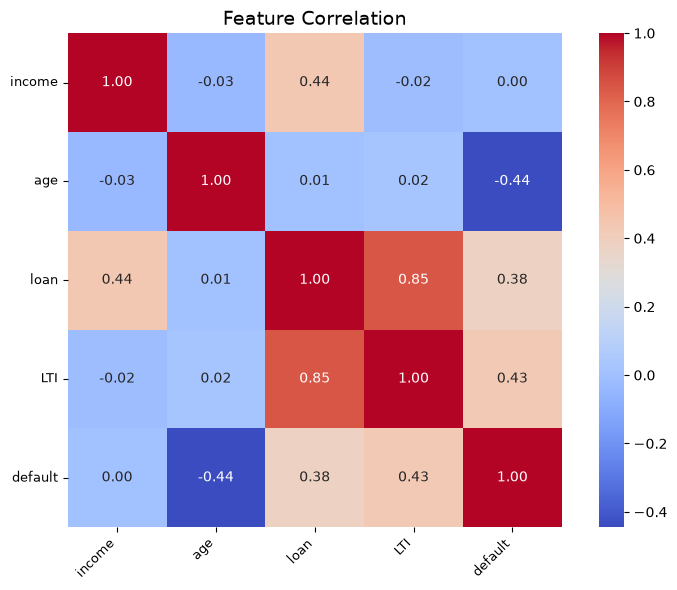

In [31]:
plt.figure(figsize = (8 , 6))
sns.heatmap(df.corr() , annot = True , square = True , fmt = ".2f" , cmap = "coolwarm")

plt.title("Feature Correlation" , fontsize = 14)
plt.xticks(rotation = 45 , ha = "right" , fontsize = 9)
plt.yticks(rotation = 0 , fontsize = 9)
plt.tight_layout()
plt.show()

### Feature & Target Split

In [32]:
X = df[["income" , "age" , "loan"]]
y = np.array(df["default"]).reshape(-1 , 1)

print(X.shape)
print(y.shape)

(2000, 3)
(2000, 1)


### Train & Test Split

In [33]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , stratify = y , random_state = 100)

y_train = np.squeeze(y_train , axis = 1)
y_test = np.squeeze(y_test , axis = 1)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1600, 3)
(1600,)
(400, 3)
(400,)


### Min Max Scaler 

In [34]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### One Hot Encoding

In [35]:
y_train = to_categorical(y_train , num_classes = 2)
y_test = to_categorical(y_test , num_classes = 2)

### Adding Layer

In [37]:
model = Sequential()
model.add(Input(shape = (X_train.shape[1] , )))
model.add(Dense(units = 10 , activation = "relu"))
model.add(Dense(units = 10 , activation = "relu"))
model.add(Dense(units = 2 , activation = "softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172 (688.00 B)

 Trainable params: 172 (688.00 B)

 Non-trainable params: 0 (0.00 B)

### Compiling Model

In [42]:
model.compile(loss = "categorical_crossentropy" , optimizer = Adam() , metrics = ["accuracy"])

### Training Model

In [43]:
history = model.fit(X_train , y_train , epochs = 30 , validation_split = 0.2)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8250 - loss: 0.5775 - val_accuracy: 0.8469 - val_loss: 0.5003
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8617 - loss: 0.4335 - val_accuracy: 0.8469 - val_loss: 0.3957
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8617 - loss: 0.3560 - val_accuracy: 0.8469 - val_loss: 0.3544
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8617 - loss: 0.3252 - val_accuracy: 0.8469 - val_loss: 0.3332
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8617 - loss: 0.3037 - val_accuracy: 0.8469 - val_loss: 0.3142
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8617 - loss: 0.2839 - val_accuracy: 0.8469 - val_loss: 0.2950
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8617 - loss: 0.2646 - val_accuracy: 0.8469 - val_loss: 0.2774
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8687 - loss: 0.2470 - val_accuracy: 0.8750 - val_loss

### History Visualization

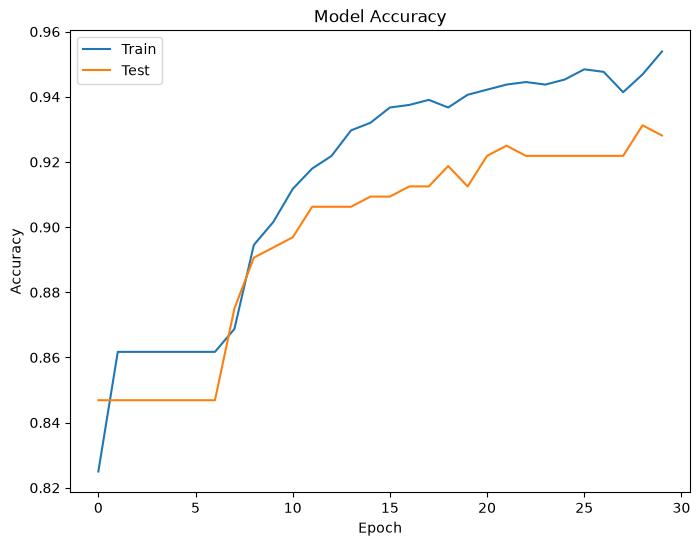

In [45]:
plt.figure(figsize = (8 , 6))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train" , "Test"])
plt.show()

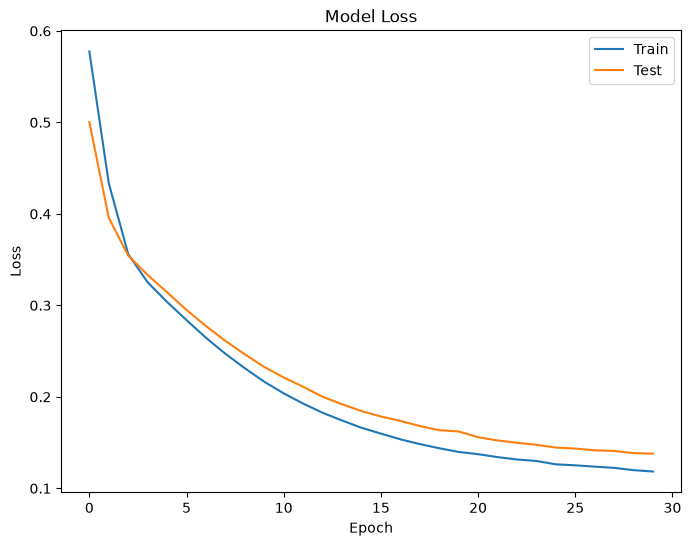

In [46]:
plt.figure(figsize = (8 , 6))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train" , "Test"])
plt.show()

### Evaluation

In [47]:
result = model.evaluate(X_test , y_test , verbose = 0)
print(f"Accuracy : {result[1]} , Loss : {result[0]}")

Accuracy : 0.9624999761581421 , Loss : 0.0926525890827179


In [50]:
print(classification_report(np.argmax(y_test , axis = 1) , np.argmax(model.predict(X_test) , axis = 1)))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       343
           1       0.90      0.82      0.86        57

    accuracy                           0.96       400
   macro avg       0.94      0.90      0.92       400
weighted avg       0.96      0.96      0.96       400



13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


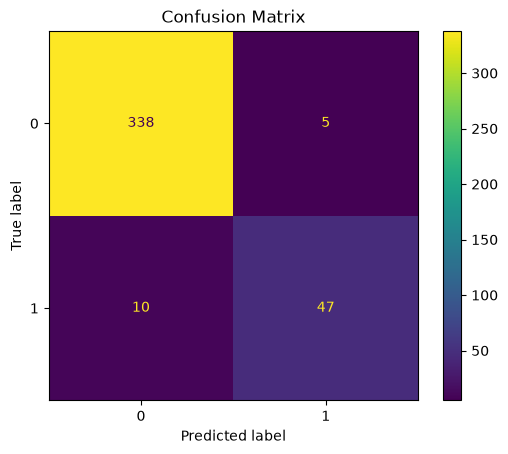

In [55]:
ConfusionMatrixDisplay.from_predictions(np.argmax(y_test , axis = 1) , np.argmax(model.predict(X_test) , axis = 1))
plt.title("Confusion Matrix")
plt.show()